In [1]:
import warnings

warnings.filterwarnings("ignore")
import os

import numpy as np
import pandas as pd
import requests
from plotly import __version__
from plotly import graph_objs as go
from plotly.offline import download_plotlyjs, init_notebook_mode, iplot, plot
from IPython.display import display, IFrame

print(__version__)  # need 1.9.0 or greater
init_notebook_mode(connected=True)

6.7.0


In [8]:
def plotly_df(df, title="", width=800, height=500):
    """Visualize all the dataframe columns as line plots."""
    common_kw = dict(x=df.index, mode="lines")
    data = [go.Scatter(y=df[c], name=c, **common_kw) for c in df.columns]
    layout = dict(title=title)
    fig = dict(data=data, layout=layout)

    plot_path = f"../../_static/plotly_htmls/{title}.html".replace(" ", "_")
    os.makedirs(os.path.dirname(plot_path), exist_ok=True)
    plot(fig, filename=plot_path, show_link=False, auto_open=False)
    iplot(fig, show_link=False)  # ← render directly in notebook instead of IFrame

Data Preparation

In [3]:
DATA_PATH = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"

In [4]:
df = pd.read_csv(DATA_PATH + "wiki_machine_learning.csv", sep=" ")
df = df[df["count"] != 0]
df.head()

,date,count,lang,page,rank,month,title
81,2015-01-01,1414,en,Machine_learning,8708,201501,Machine_learning
80,2015-01-02,1920,en,Machine_learning,8708,201501,Machine_learning
79,2015-01-03,1338,en,Machine_learning,8708,201501,Machine_learning
78,2015-01-04,1404,en,Machine_learning,8708,201501,Machine_learning
77,2015-01-05,2264,en,Machine_learning,8708,201501,Machine_learning


In [5]:
df.shape

(383, 7)

Predicting with FB Prophet

In [6]:
df.date = pd.to_datetime(df.date)

In [9]:
plotly_df(df=df.set_index("date")[["count"]], title="assign9_plot")

In [10]:
from prophet import Prophet

In [11]:
predictions = 30

df = df[["date", "count"]]
df.columns = ["ds", "y"]
df.tail()

,ds,y
382,2016-01-16,1644
381,2016-01-17,1836
376,2016-01-18,2983
375,2016-01-19,3389
372,2016-01-20,3559


In [12]:
train_df = df[:-predictions].copy()

In [13]:
m = Prophet()
m.fit(train_df)

19:11:43 - cmdstanpy - INFO - Chain [1] start processing
19:11:43 - cmdstanpy - INFO - Chain [1] done processing


In [14]:
future = m.make_future_dataframe(periods=predictions)
future.tail()

,ds
378,2016-01-16
379,2016-01-17
380,2016-01-18
381,2016-01-19
382,2016-01-20


In [15]:
forecast = m.predict(future)
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
378,2016-01-16,2974.983364,1695.476031,2511.852651,2955.331237,2993.007577,-861.674222,-861.674222,-861.674222,-861.674222,-861.674222,-861.674222,0.0,0.0,0.0,2113.309142
379,2016-01-17,2980.321813,1850.736948,2678.309601,2959.517417,2999.285871,-720.694652,-720.694652,-720.694652,-720.694652,-720.694652,-720.694652,0.0,0.0,0.0,2259.627161
380,2016-01-18,2985.660263,2859.946325,3693.657787,2963.602625,3006.085149,281.402427,281.402427,281.402427,281.402427,281.402427,281.402427,0.0,0.0,0.0,3267.062689
381,2016-01-19,2990.998712,3093.092646,3980.534446,2967.738834,3012.609552,541.386336,541.386336,541.386336,541.386336,541.386336,541.386336,0.0,0.0,0.0,3532.385048
382,2016-01-20,2996.337162,3030.291364,3816.206456,2971.920133,3018.807703,425.486824,425.486824,425.486824,425.486824,425.486824,425.486824,0.0,0.0,0.0,3421.823986


Q1: Question 1: What is the prediction of the number of views of the wiki page on January 20? Round to the nearest integer.

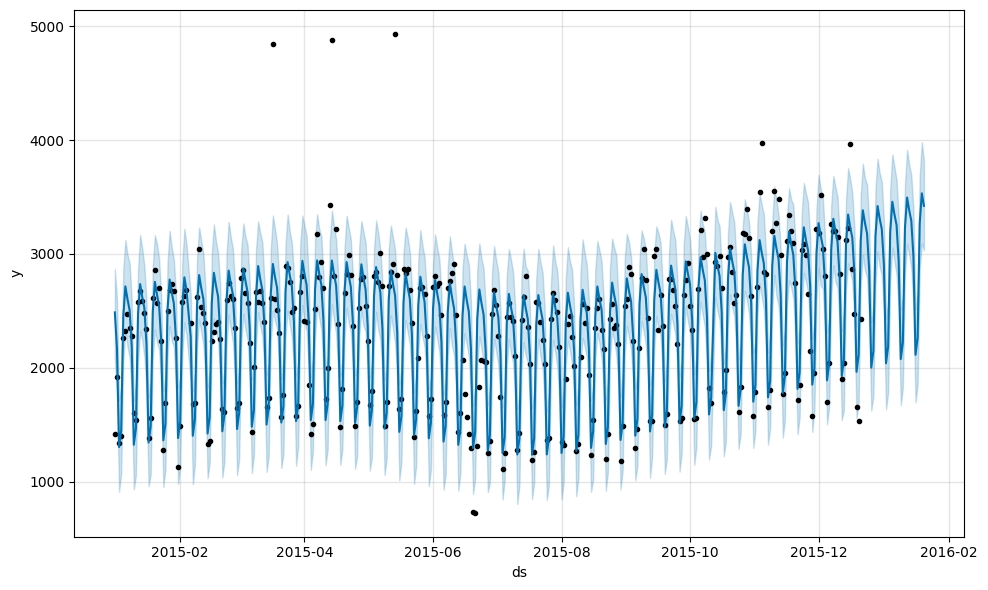

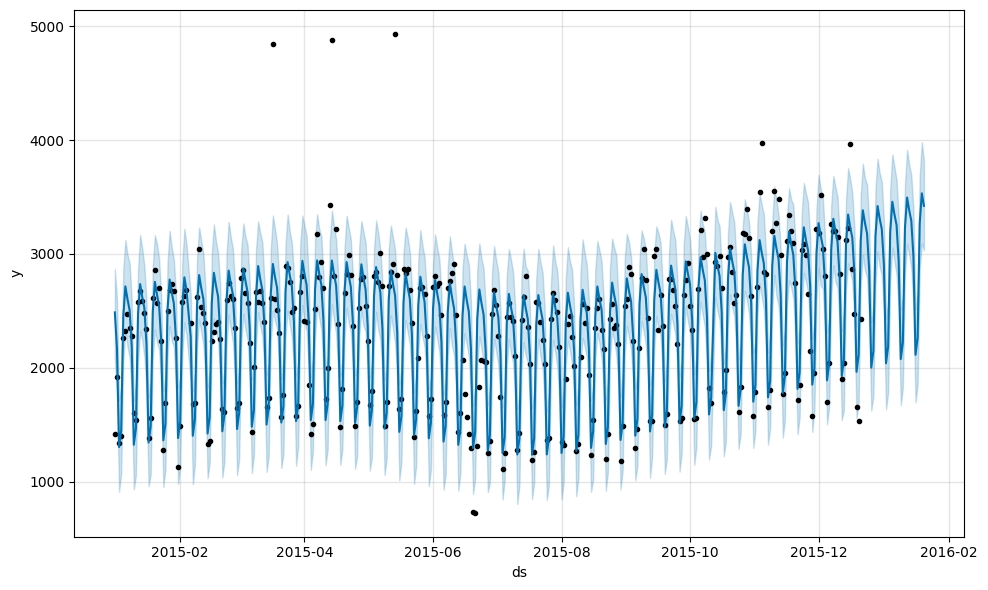

In [16]:
m.plot(forecast)

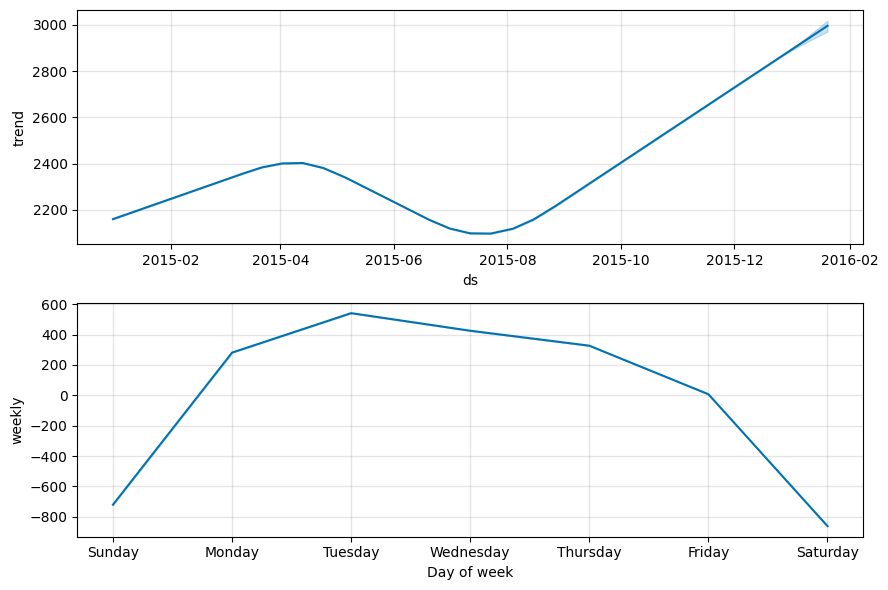

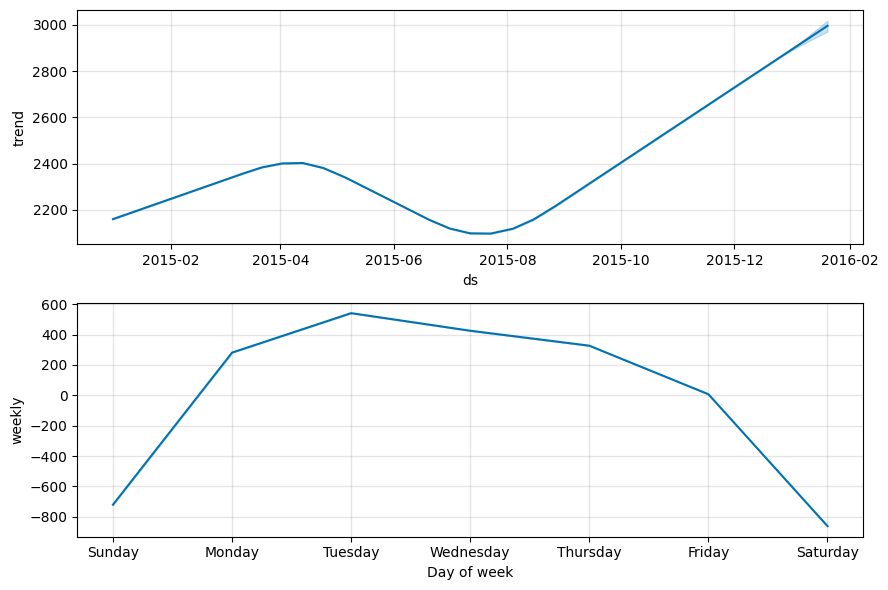

In [17]:
m.plot_components(forecast)

In [18]:
cmp_df = forecast.set_index("ds")[["yhat", "yhat_lower", "yhat_upper"]].join(
    df.set_index("ds")
)

In [19]:
cmp_df["e"] = cmp_df["y"] - cmp_df["yhat"]
cmp_df["p"] = 100 * cmp_df["e"] / cmp_df["y"]
print("MAPE = ", round(np.mean(abs(cmp_df[-predictions:]["p"])), 2))
print("MAE = ", round(np.mean(abs(cmp_df[-predictions:]["e"])), 2))

MAPE =  34.35
MAE =  596.54


Predicting with ARIMA

In [20]:
%matplotlib inline
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

plt.rcParams["figure.figsize"] = (15, 10)

Question 4: Let’s verify the stationarity of the series using the Dickey-Fuller test. Is the series stationary? What is the p-value?

Dickey-Fuller test: p=0.107392


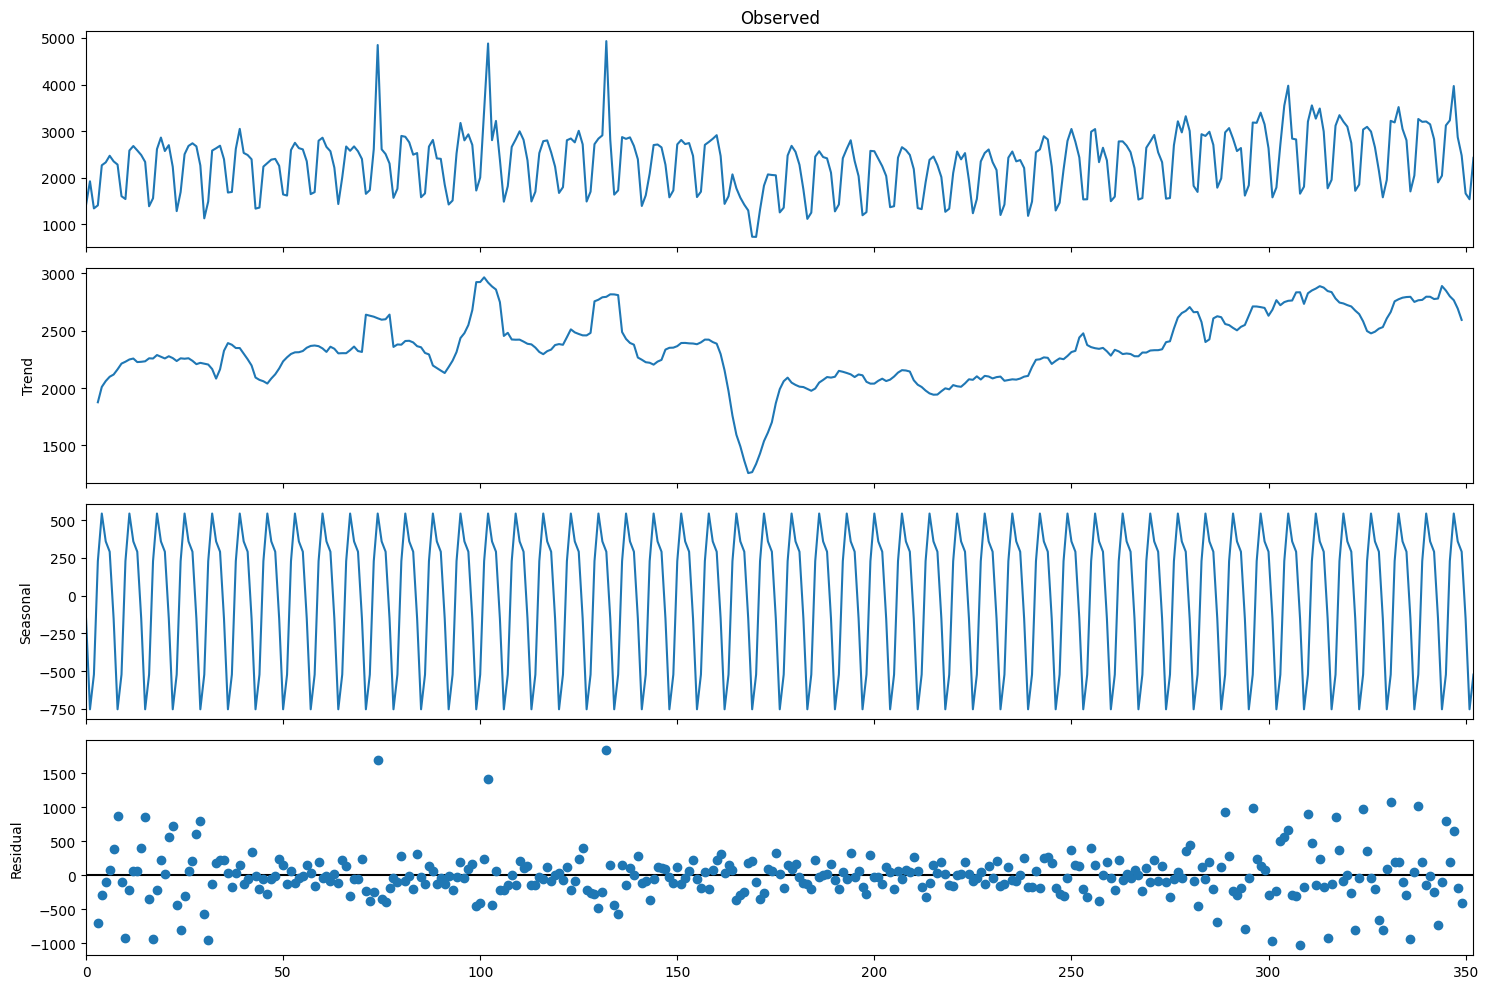

In [21]:
sm.tsa.seasonal_decompose(train_df["y"].values, period=7).plot()
print("Dickey-Fuller test: p=%f" % sm.tsa.stattools.adfuller(train_df["y"])[1])

In [22]:
train_df.set_index("ds", inplace=True)

Dickey-Fuller test: p=0.000000


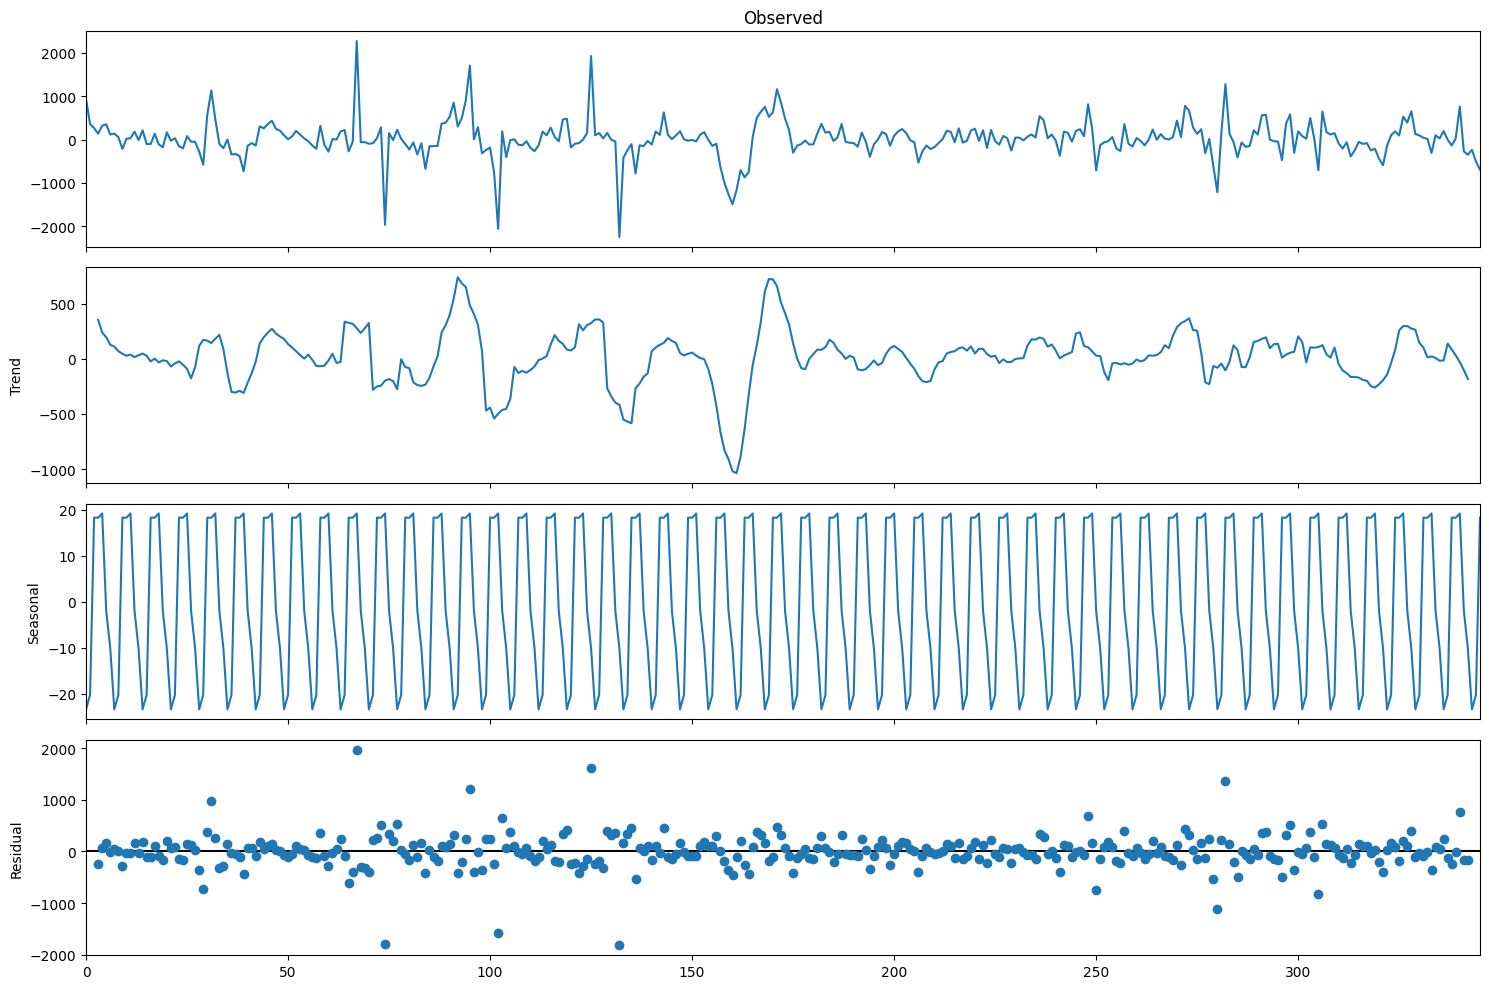

In [23]:
train_df["y_diff"] = train_df.y - train_df.y.shift(7)
sm.tsa.seasonal_decompose(train_df.y_diff[7:].values, period=7).plot()
print("Dickey-Fuller test: p=%f" % sm.tsa.stattools.adfuller(train_df.y_diff[8:])[1])

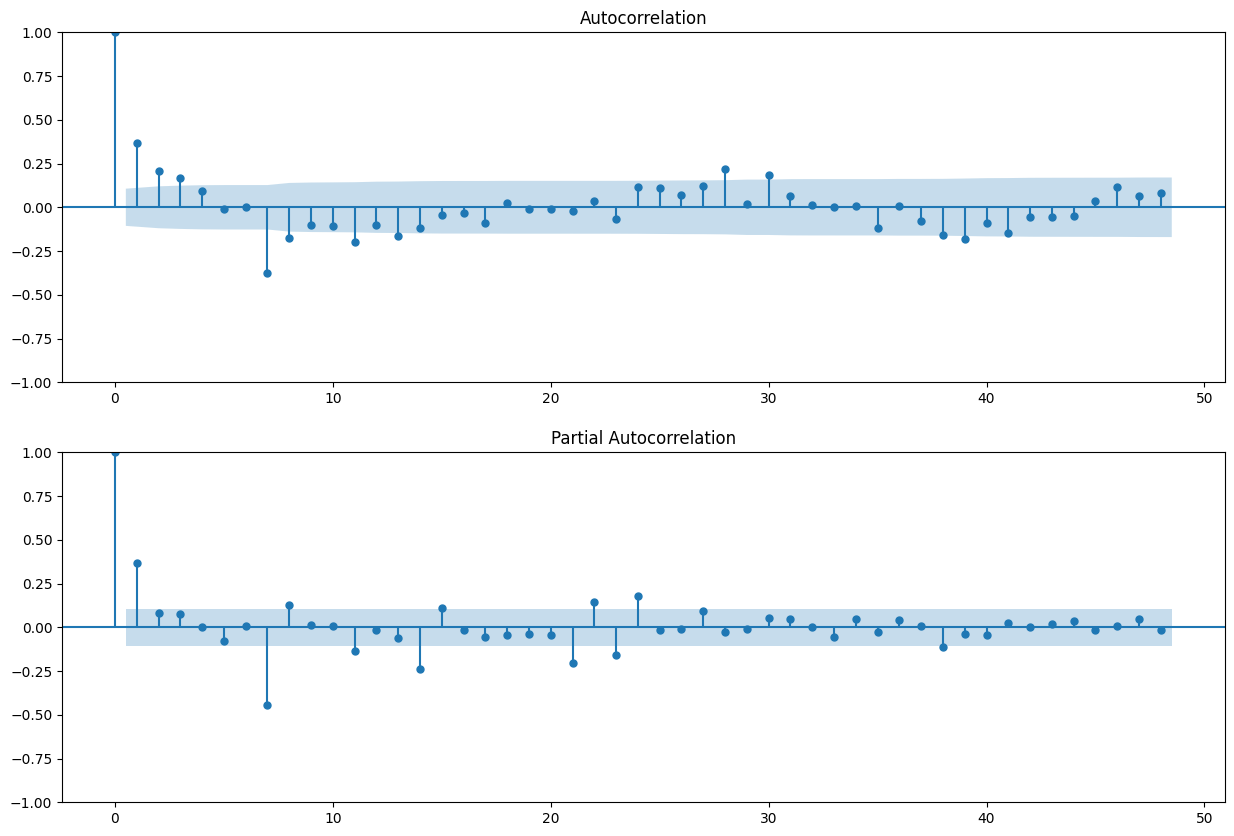

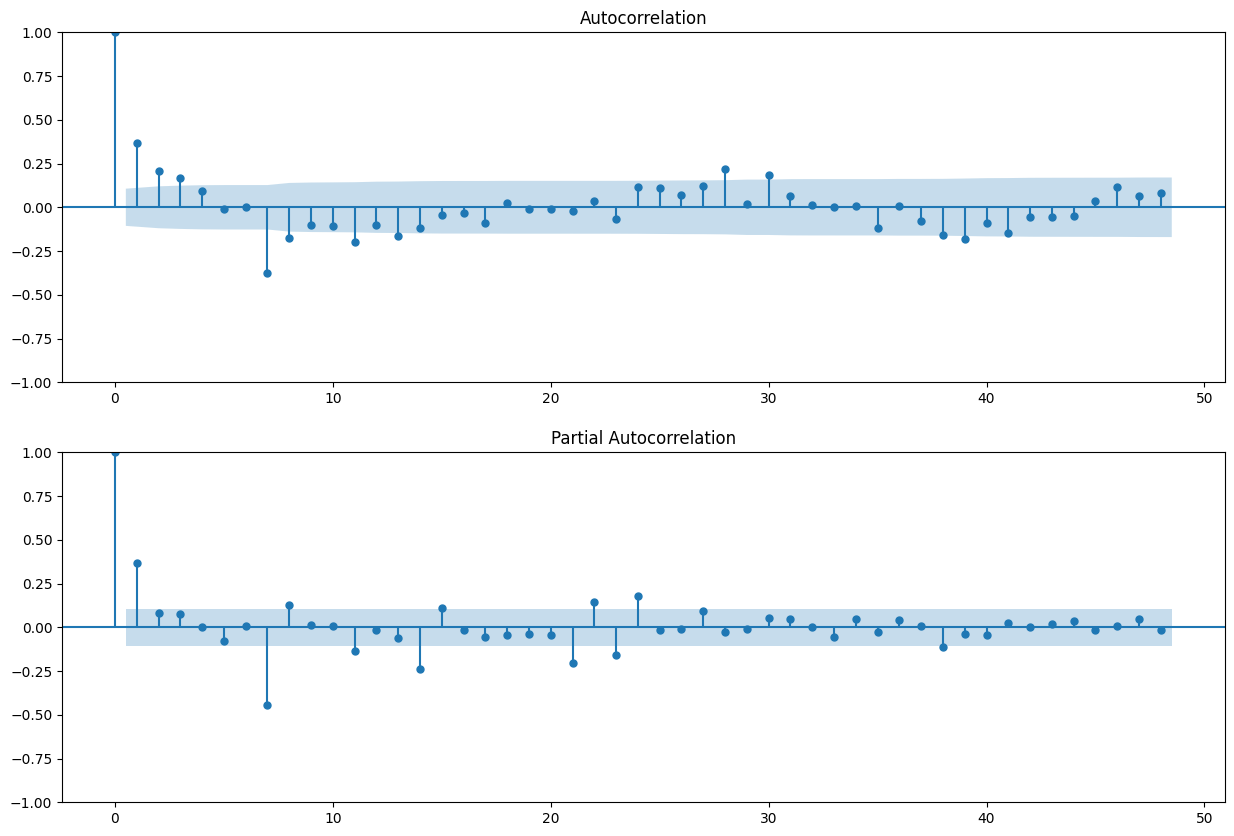

In [24]:
ax = plt.subplot(211)
sm.graphics.tsa.plot_acf(train_df.y_diff[13:].values.squeeze(), lags=48, ax=ax)

ax = plt.subplot(212)
sm.graphics.tsa.plot_pacf(train_df.y_diff[13:].values.squeeze(), lags=48, ax=ax)

In [25]:
ps = range(0, 2)
ds = range(0, 2)
qs = range(0, 4)
Ps = range(0, 4)
Ds = range(0, 3)
Qs = range(0, 2)

In [26]:
from itertools import product

parameters = product(ps, ds, qs, Ps, Ds, Qs)
parameters_list = list(parameters)
len(parameters_list)

384

In [27]:
%%time
import warnings

from tqdm.notebook import tqdm

results1 = []
best_aic = float("inf")
warnings.filterwarnings("ignore")

for param in tqdm(parameters_list):
    # try except is necessary, because on some sets of parameters the model can not be trained
    try:
        model = sm.tsa.statespace.SARIMAX(
            train_df["y"],
            order=(param[0], param[1], param[2]),
            seasonal_order=(param[3], param[4], param[5], 7),
            # train the model as is even if that would lead to a non-stationary / non-invertible model
            # see https://github.com/statsmodels/statsmodels/issues/6225 for details
        ).fit(disp=-1)

    except (ValueError, np.linalg.LinAlgError):
        continue

    aic = model.aic
    # save the best model, aic, parameters
    if aic < best_aic:
        best_model = model
        best_aic = aic
        best_param = param
    results1.append([param, model.aic])

  0%|          | 0/384 [00:00<?, ?it/s]

CPU times: user 5h 55min 1s, sys: 1min 40s, total: 5h 56min 41s
Wall time: 45min 20s


In [28]:
result_table1 = pd.DataFrame(results1)
result_table1.columns = ["parameters", "aic"]
print(result_table1.sort_values(by="aic", ascending=True).head())

             parameters        aic
59   (0, 0, 2, 2, 0, 0)  10.000000
42   (0, 0, 1, 3, 0, 1)  12.000000
66   (0, 0, 2, 3, 0, 1)  14.000000
330  (1, 1, 1, 3, 0, 1)  14.000000
378  (1, 1, 3, 3, 0, 1)  52.721213


In [29]:
result_table1[
    result_table1["parameters"].isin(
        [(1, 0, 2, 3, 1, 0), (1, 1, 2, 3, 2, 1), (1, 1, 2, 3, 1, 1), (1, 0, 2, 3, 0, 0)]
    )
].sort_values(by="aic")

,parameters,aic
358,"(1, 1, 2, 3, 2, 1)",4988.989473
356,"(1, 1, 2, 3, 1, 1)",5019.555903
259,"(1, 0, 2, 3, 1, 0)",5022.312524
257,"(1, 0, 2, 3, 0, 0)",5183.584907


In [30]:
import scipy.stats

train_df["y_box"], lmbda = scipy.stats.boxcox(train_df["y"])
print("The optimal Box-Cox transformation parameter: %f" % lmbda)

The optimal Box-Cox transformation parameter: 0.732841


In [31]:
results2 = []
best_aic = float("inf")

for param in tqdm(parameters_list):
    # try except is necessary, because on some sets of parameters the model can not be trained
    try:
        model = sm.tsa.statespace.SARIMAX(
            train_df["y_box"],
            order=(param[0], param[1], param[2]),
            seasonal_order=(param[3], param[4], param[5], 7),
            # train the model as is even if that would lead to a non-stationary / non-invertible model
            # see https://github.com/statsmodels/statsmodels/issues/6225 for details
            enforce_stationarity=False,
            enforce_invertibility=False  
        ).fit(disp=-1)

    except (ValueError, np.linalg.LinAlgError):
        continue

    aic = model.aic
    # save the best model, aic, parameters
    if aic < best_aic:
        best_model = model
        best_aic = aic
        best_param = param
    results2.append([param, model.aic])

warnings.filterwarnings("default")

  0%|          | 0/384 [00:00<?, ?it/s]

In [32]:
result_table2 = pd.DataFrame(results2)
result_table2.columns = ["parameters", "aic"]
print(result_table2.sort_values(by="aic", ascending=True).head())

             parameters          aic
263  (1, 0, 2, 3, 2, 1)  3292.640166
287  (1, 0, 3, 3, 2, 1)  3294.134383
215  (1, 0, 0, 3, 2, 1)  3294.194179
239  (1, 0, 1, 3, 2, 1)  3296.022150
383  (1, 1, 3, 3, 2, 1)  3296.540787


In [33]:
result_table2[
    result_table2["parameters"].isin(
        [(1, 0, 2, 3, 1, 0), (1, 1, 2, 3, 2, 1), (1, 1, 2, 3, 1, 1), (1, 0, 2, 3, 0, 0)]
    )
].sort_values(by="aic")

,parameters,aic
359,"(1, 1, 2, 3, 2, 1)",3326.066514
357,"(1, 1, 2, 3, 1, 1)",3335.179337
260,"(1, 0, 2, 3, 1, 0)",3335.555977
258,"(1, 0, 2, 3, 0, 0)",3510.553758


Question 5: What parameters are the best for the model according to the AIC criterion?

In [34]:
best_model = sm.tsa.statespace.SARIMAX(
    train_df["y_box"],
    order=(1, 0, 2),
    seasonal_order=(3, 2, 1, 7),
    enforce_stationarity=False,  
    enforce_invertibility=False  
).fit(disp=-1)

/home/user/projects/ml-course/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [35]:
print(best_model.summary())

                                      SARIMAX Results                                      
Dep. Variable:                               y_box   No. Observations:                  353
Model:             SARIMAX(1, 0, 2)x(3, 2, [1], 7)   Log Likelihood               -1638.320
Date:                             Mon, 08 Jun 2026   AIC                           3292.640
Time:                                     20:21:21   BIC                           3322.711
Sample:                                          0   HQIC                          3304.652
                                             - 353                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8153      0.115      7.091      0.000       0.590       1.041
ma.L1         -0.3308      

Student's test: p=0.293588
Dickey-Fuller test: p=0.000000


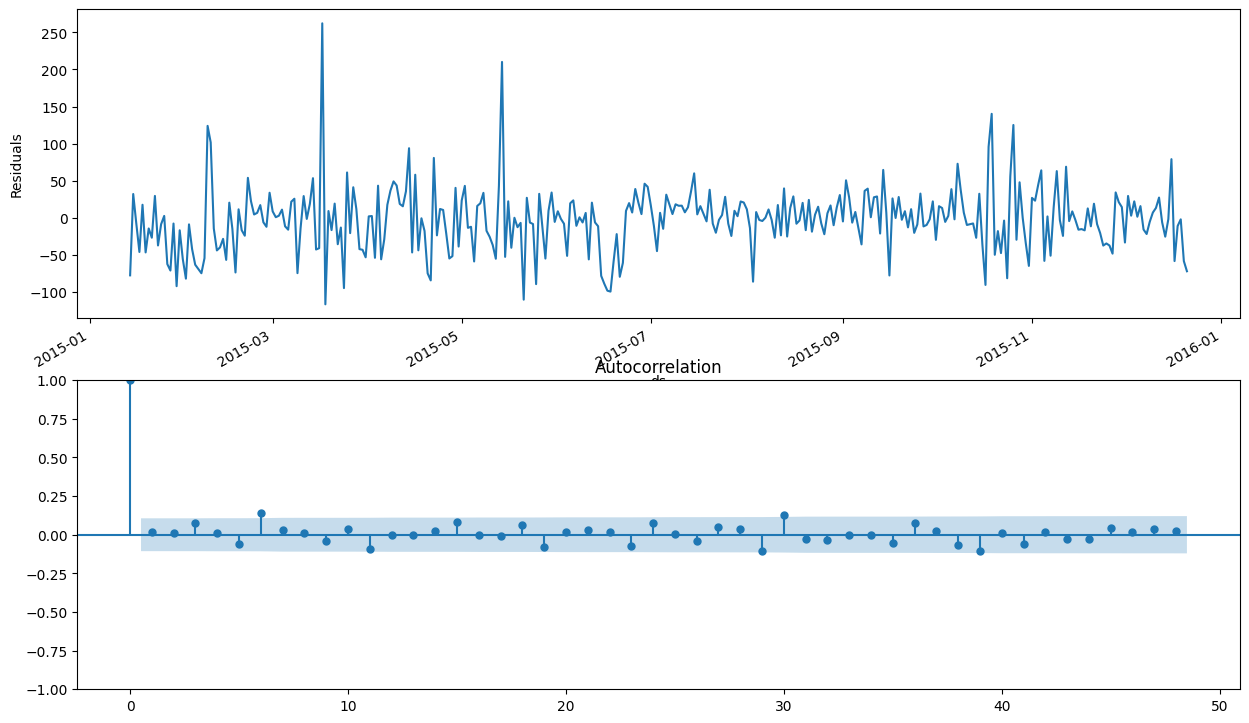

In [36]:
plt.subplot(211)
best_model.resid[13:].plot()
plt.ylabel(u"Residuals")

ax = plt.subplot(212)
sm.graphics.tsa.plot_acf(best_model.resid[13:].values.squeeze(), lags=48, ax=ax)

print("Student's test: p=%f" % stats.ttest_1samp(best_model.resid[13:], 0)[1])
print("Dickey-Fuller test: p=%f" % sm.tsa.stattools.adfuller(best_model.resid[13:])[1])

In [37]:
def invboxcox(y, lmbda):
    # reverse Box Cox transformation
    if lmbda == 0:
        return np.exp(y)
    else:
        return np.exp(np.log(lmbda * y + 1) / lmbda)

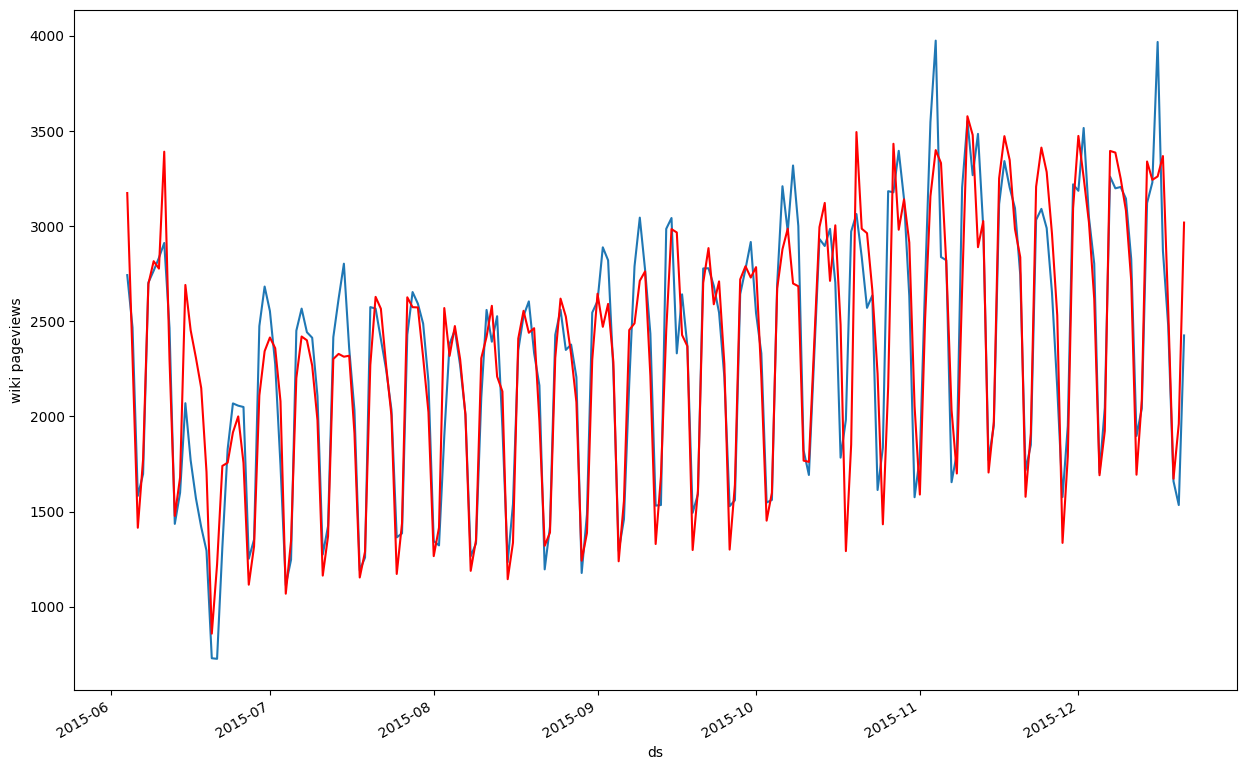

In [38]:
train_df["arima_model"] = invboxcox(best_model.fittedvalues, lmbda)

train_df.y.tail(200).plot()
train_df.arima_model[13:].tail(200).plot(color="r")
plt.ylabel("wiki pageviews");